                        TASK-1

Problem 1

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [3]:
print(tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

GPU is not detected so i will still explain why CPU is slower than GPU as it has very fewer cores than GPU and as CPU is optimised for sequential processing but on the other hand GPU is optimised on parallel computation.               On GPU the different ways we use are-using larger batch size due to its capacity to process bigger data                                               -training more complex data                        -using more epochs in lesser duration.             We are setting random seeds to ensure rperoducibility as if we use without seeds every run will give different results so to get same output every time we use seeds.                  ALL seeds controls different randomness astf.random.set_seed(42) tenflow (trains model) and controls neural network operations ,np.random.seed(42) controls numpy array operations,rnamdom seeds(42) control python randomm functions.

Problem 2

In [5]:
from tensorflow.keras.datasets import mnist, cifar10

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [6]:
print("MNIST Training Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("CIFAR-10 Training Shape:", x_train_cifar.shape)
print("CIFAR-10 Test Shape:", x_test_cifar.shape)

MNIST Training Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR-10 Training Shape: (50000, 32, 32, 3)
CIFAR-10 Test Shape: (10000, 32, 32, 3)


In [7]:
print("\nMNIST Data Type:", x_train_mnist.dtype)
print("MNIST Pixel Range:", x_train_mnist.min(), "to", x_train_mnist.max())

print("\nCIFAR-10 Data Type:", x_train_cifar.dtype)
print("CIFAR-10 Pixel Range:", x_train_cifar.min(), "to", x_train_cifar.max())


MNIST Data Type: uint8
MNIST Pixel Range: 0 to 255

CIFAR-10 Data Type: uint8
CIFAR-10 Pixel Range: 0 to 255


In [8]:
unique, counts = np.unique(y_train_mnist, return_counts=True)

print("\nMNIST Class Distribution:")
for i in range(len(unique)):
    print("Digit", unique[i], ":", counts[i], "samples")


MNIST Class Distribution:
Digit 0 : 5923 samples
Digit 1 : 6742 samples
Digit 2 : 5958 samples
Digit 3 : 6131 samples
Digit 4 : 5842 samples
Digit 5 : 5421 samples
Digit 6 : 5918 samples
Digit 7 : 6265 samples
Digit 8 : 5851 samples
Digit 9 : 5949 samples


(a) Shape of dataset=
MNIST training shape= (60000, 28, 28)
MNIST test shape= (10000, 28, 28)
CIFAR-10 training shape= (50000, 32, 32, 3)
CIFAR-10 test shape= (10000, 32, 32, 3)            (b) Data types and pixel range=
Data types of image(MNIST and CIFAR-10)= uint8
Pixel values range from= 0 to 255 For both MNIST and CIFAR-10                                       (c) Class distributions in MNIST=
Each digit (0–9) has approximately 6000 samples
So,we can say that the dataset is balanced because all classes have almost similar number of samples.

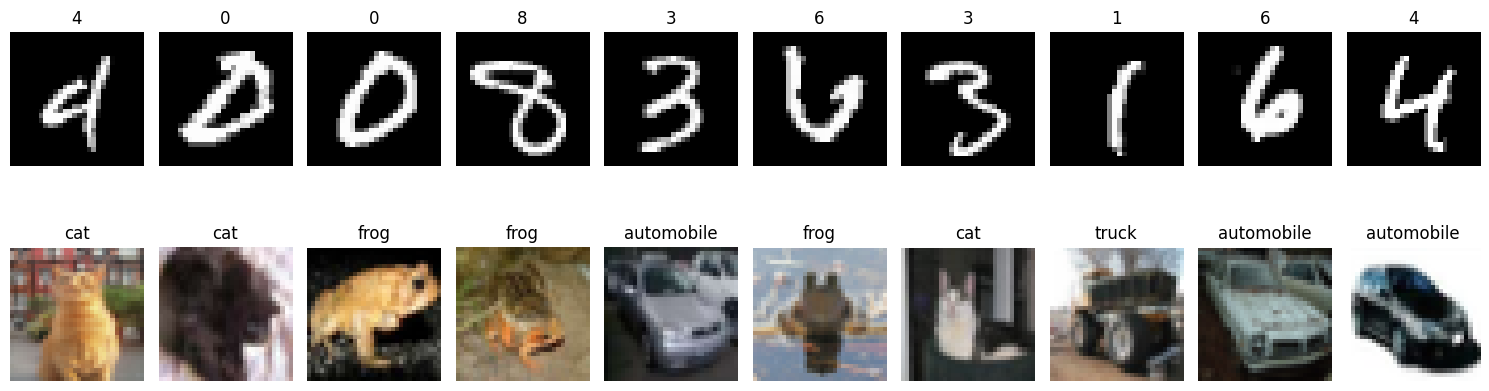

In [9]:
import matplotlib.pyplot as plt
import numpy as np


cifar_classes = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

plt.figure(figsize=(15,5))

mnist_indices = np.random.choice(len(x_train_mnist), 10)

for i, idx in enumerate(mnist_indices):
    plt.subplot(2, 10, i+1)
    plt.imshow(x_train_mnist[idx], cmap='gray')
    plt.title(y_train_mnist[idx])
    plt.axis('off')


cifar_indices = np.random.choice(len(x_train_cifar), 10)

for i, idx in enumerate(cifar_indices):
    plt.subplot(2, 10, i+11)
    plt.imshow(x_train_cifar[idx])
    plt.title(cifar_classes[y_train_cifar[idx][0]])
    plt.axis('off')


plt.tight_layout()

plt.show()

Problem 3

Normalisation

In [10]:
x_train_mnist = x_train_mnist.astype('float32') / 255.0

In [11]:
print("After normalization:")
print("Data type:", x_train_mnist.dtype)
print("Range:", x_train_mnist.min(), "to", x_train_mnist.max())

After normalization:
Data type: float32
Range: 0.0 to 1.0


Reshape

In [12]:
x_train_mnist = x_train_mnist.reshape(-1,28,28,1)

In [13]:
print("\nAfter reshaping:")
print("Shape:", x_train_mnist.shape)


After reshaping:
Shape: (60000, 28, 28, 1)


one-hot

In [14]:
y_onehot = np.zeros((len(y_train_mnist),10))
for i in range(len(y_train_mnist)):
    y_onehot[i, y_train_mnist[i]] = 1

In [15]:
print("\nAfter one-hot encoding:")
print("Shape:", y_onehot.shape)
print("Sample:\n", y_onehot[:5])


After one-hot encoding:
Shape: (60000, 10)
Sample:
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


Problem4

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

In [17]:
indices = np.random.choice(len(x_train_cifar), 5)
sample_images = x_train_cifar[indices]

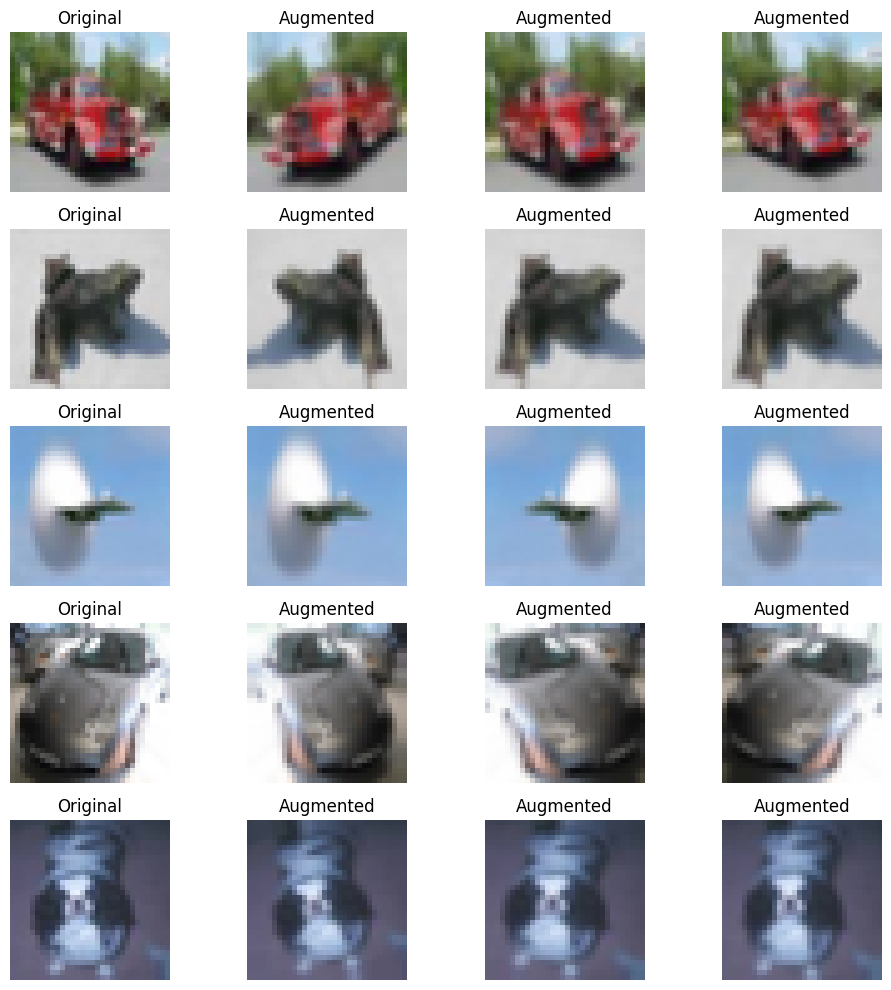

In [18]:
plt.figure(figsize=(10,10))

for i in range(5):

    plt.subplot(5, 4, i*4 + 1)
    plt.imshow(sample_images[i])
    plt.title("Original")
    plt.axis('off')

    img = sample_images[i].reshape((1,32,32,3))

    aug_iter = datagen.flow(img, batch_size=1)

    for j in range(3):
        aug_img = next(aug_iter)[0].astype('uint8')

        plt.subplot(5, 4, i*4 + 2 + j)
        plt.imshow(aug_img)
        plt.title("Augmented")
        plt.axis('off')

plt.tight_layout()

plt.show()

Augmenation only works for training dataset because as it helps the model to learn better by increasing the diversity of data and reducing its overfitting.The test set must not change so it can represent real-world data and do the fair evaluation of model's performance.Due to applying augmentaion it can give misleading results and make performance evalution incorrect.

ANALYTICAL QUESTIONS

Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the same input with the same number of filters. Which uses fewer parameters? Show numerical proof and explain any other advantages of the smaller kernel approach.                                  ANS.One 5×5 Convo Layer

Parameter formula:
Params=(5X5XC+1)XF                               Two 3×3 Conv Layers
First layer:(3×3×C+1)×F=(9C+1)F
Second layer:

Input channels = F
(3×3×F+1)×F=(9F+1)F                               Total parameters:
(9C+1)F+(9F+1)F                                    Although two 3×3 layers have more parameters than one 5×5 layer but Two 3×3 layers give Same receptive field (5×5)But more non-linearity.      numeerical-Let,

C = 3 (RGB image)
F = 64 filters                                    for 5×5 layer,(25×3+1)×64=(75+1)×64=76×64=4864
for two 3x3 layer,(9×3+1)×64=(27+1)×64=28×64=1792  (9×3+1)×64=(27+1)×64=28×64=1792,1792+36928=38720

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or
after activation), and why? Mention at least two empirical benefits it provides during training.                                        ANS.Batch normalisation is used to normalize the output of a layer so that it has(mean ≈ 0,variance ≈ 1).This makes training more stable and faster.   Batch norm is placed before activation,placing it before activation function gives better and more stable results.it has higher learning rate and it act as regulisation.

Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head. What does this layer do
geometrically? What would happen to the parameter count and spatial information if you replaced it with
Flatten?                                        ANS.GAP layer takes each feature map and computes the average of all the values of the map.Parameter Count with GAP is very few parameters as Output size is equal to C but for Flatten Output size is H × W × C which is much bigger input to Dense layer and creates large increase in parameters.


                                       TASK-2

Problem 1

In [19]:
def conv2d(image, kernel, stride=1, padding=0):

    H, W = image.shape
    kH, kW = kernel.shape

    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')


    H_p, W_p = image.shape

    out_H = (H_p - kH) // stride + 1
    out_W = (W_p - kW) // stride + 1


    output = np.zeros((out_H, out_W))


    for i in range(out_H):
        for j in range(out_W):


            patch = image[i*stride:i*stride+kH, j*stride:j*stride+kW]


            output[i, j] = np.sum(patch * kernel)

    return output



In [20]:
image = np.array([
    [3,1,0,2,4],[1,5,3,2,1],[0,2,6,4,3],[2,3,1,5,2],[1,0,2,3,4]
])

In [21]:
kernel = np.array([
    [-1,0,1],[-2,0,2], [-1,0,1]
])

In [22]:
output = conv2d(image, kernel, stride=1, padding=0)

print("Output Feature Map:\n", output)
print("Output Shape:", output.shape)

Output Feature Map:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


Problem 2

Output=[(Input−Kernel+2×Padding)/stride​]+1       a)[(28−5+0)/1]​+1=23+1=24 ,ans is 24x24                                             b)[(28−3+2)/1]​+1=27+1=28  ,ans is 28x28                                             c)[(32−3+0)/2]​+1=29/2​+1=15.5 so value is 15x15                                             d)First Layer,

Input = 32
K = 3, P = 1, S = 1
[(32−3+2)/1]=31+1=32                             Second Layer,

Input = 32
K = 3, P = 0, S = 1
[(32−3+0)/1]=29+1=30
	​
ans is 30x30


Problem 3

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Dense, Flatten

model = Sequential()

model.add(Conv2D(6, (5,5), activation='tanh', padding='valid', input_shape=(28,28,1)))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

model.add(Conv2D(16, (5,5), activation='tanh', padding='valid'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

model.add(Flatten())
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

(b) Manual Parameter Calculation (First Conv Layer)=                              Params=(K×K×C+1)×C
out
	​


For first layer:

K = 5
C_in = 1 (grayscale MNIST)
C_out = 6

=(5×5×1+1)×6

=(25+1)×6=26×6=156                                                           (c) Why AvgPooling in LeNet-5 vs MaxPooling today?                           ANS.In LeNet-5, Average Pooling was used because early CNNs focused on smoothing features and reducing sensitivity to noise by averaging values in a region. But modern CNNs prefer MaxPooling because it selects the strongest activation, which helps preserve important features like edges and textures. MaxPooling also works better with ReLU activations and improves performance in deep networks.                                                               

Problem 4

a)Input (32×32×3)

↓ Conv Block 1
Conv2D(32) → BatchNorm → ReLU → MaxPool

↓ Conv Block 2
Conv2D(64) → BatchNorm → ReLU → MaxPool

↓ Conv Block 3
Conv2D(128) → BatchNorm → ReLU → MaxPool

↓ GlobalAveragePooling

↓ Dense(128) → ReLU

↓ Dropout(0.5)

↓ Dense(10) → Softmax (Output)                                                  b)This model uses three convolutional blocks to progressively extract features from low-level edges to high-level patterns. Batch Normalisation is applied after each convolution to stabilize training and improve convergence. MaxPooling is used to reduce spatial dimensions and control overfitting. GlobalAveragePooling9GAP) reduces the number of parameters before the Dense layers, and Dropout is added to prevent overfitting. The architecture balances complexity and efficiency to perform well on CIFAR-1.                     

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()


model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

Now the expected parameter count is ~300K – 600K which is in the expected range of (200K–2M).

ANALYTICAL QUESTIONS

Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus one 5×5 Conv layer on the
same input with the same number of filters. Which uses fewer parameters? Show numerical proof and
explain any other advantages of the smaller kernel approach?                 ANS.On comparing One 5×5 Conv layer and two stacked 3×3 Conv layers Input ,we will assume channels = C and Number of filters = F                           for One 5×5 Convolution Layer Params=(5×5×C+1)×F=(25C+1)F                    for two 3×3 Convolution Layers
First layer:
(3×3×C+1)×F=(9C+1)F
Second layer:
(3×3×F+1)×F=(9F+1)F
Total:(9C+1)F+(9F+1)F                                                         ex.C=3,F=64                                                                    for 5×5 Conv:(25×3+1)×64=(75+1)×64=76×64=4864                                   for two 3×3 Conv:
First layer:(9×3+1)×64=28×64=1792
Second layer:(9×64+1)×64=577×64=36928
Total:1792+36928=38720                                                          Although two stacked 3×3 convolution layers may use more parameters when the number of filters is the same, they are preferred because they provide the same receptive field as a 5×5 layer while introducing additional non-linearity and improving feature learning.

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack should it be placed (before or
after activation), and why? Mention at least two empirical benefits it provides during training?                                                                ANS.Batch Normalisation is used to normalize the output of a layer so that the
mean ≈ 0 and Variance ≈ 1.This helps make training faster and more stable.it is placd before activation function to improve learning and stability.             Its two empirical benefits are 1) Faster Convergence in which model trains faster and requires fewer epochs.                                               2)it allows higher Learning Rate.     

Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head. What does this layer do
geometrically? What would happen to the parameter count and spatial information  if you replaced it with
Flatten?                                                                     ANS.GlobalAveragePooling (GAP) layer takes each feature map and computes the average of all the values in it.If it is replaced with flatten then there will be huge increase in parameters and GAP loses spatial information (position of features)and keeps overall presence of features while Flatten preserves spatial arrangement keeps detailed structure of features.

                                                    TASK-3

Problem 1